1 Overview

In [78]:
import kagglehub
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import kstest, norm
from collections import Counter
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')

# Целевая переменная: Price 
cache_path = kagglehub.dataset_download("vishakhdapat/price-of-used-toyota-corolla-cars")

csv_filename = [f for f in os.listdir(cache_path) if f.endswith('.csv')][0]
source_file = os.path.join(cache_path, csv_filename)

local_file_name = 'toyota_data.csv'
shutil.copy(source_file, local_file_name)

dataset = pd.read_csv('toyota_data.csv')
# Уберем, тк он не нужен 
dataset.drop('Id', axis=1, inplace=True)
# Переименуем в Age
dataset.rename(columns={'Age_08_04': 'Age'}, inplace=True) 
dataset.head(3)


,Model,Price,Age,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,Blue,...,1,1,0,0,0,1,0,0,0,0
1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,Silver,...,0,1,0,0,0,1,0,0,0,0
2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,Blue,...,0,1,0,0,0,1,0,0,0,0


In [79]:
print("Количество записей:\n", dataset.count())
print("\nСтатистика:\n", dataset.describe())
print("\nПропуски:\n", dataset.isnull().sum())


Количество записей:
 Model                1436
Price                1436
Age                  1436
Mfg_Month            1436
Mfg_Year             1436
KM                   1436
Fuel_Type            1436
HP                   1436
Met_Color            1436
Color                1436
Automatic            1436
CC                   1436
Doors                1436
Cylinders            1436
Gears                1436
Quarterly_Tax        1436
Weight               1436
Mfr_Guarantee        1436
BOVAG_Guarantee      1436
Guarantee_Period     1436
ABS                  1436
Airbag_1             1436
Airbag_2             1436
Airco                1436
Automatic_airco      1436
Boardcomputer        1436
CD_Player            1436
Central_Lock         1436
Powered_Windows      1436
Power_Steering       1436
Radio                1436
Mistlamps            1436
Sport_Model          1436
Backseat_Divider     1436
Metallic_Rim         1436
Radio_cassette       1436
Parking_Assistant    1436
Tow_Bar          

2 EDA


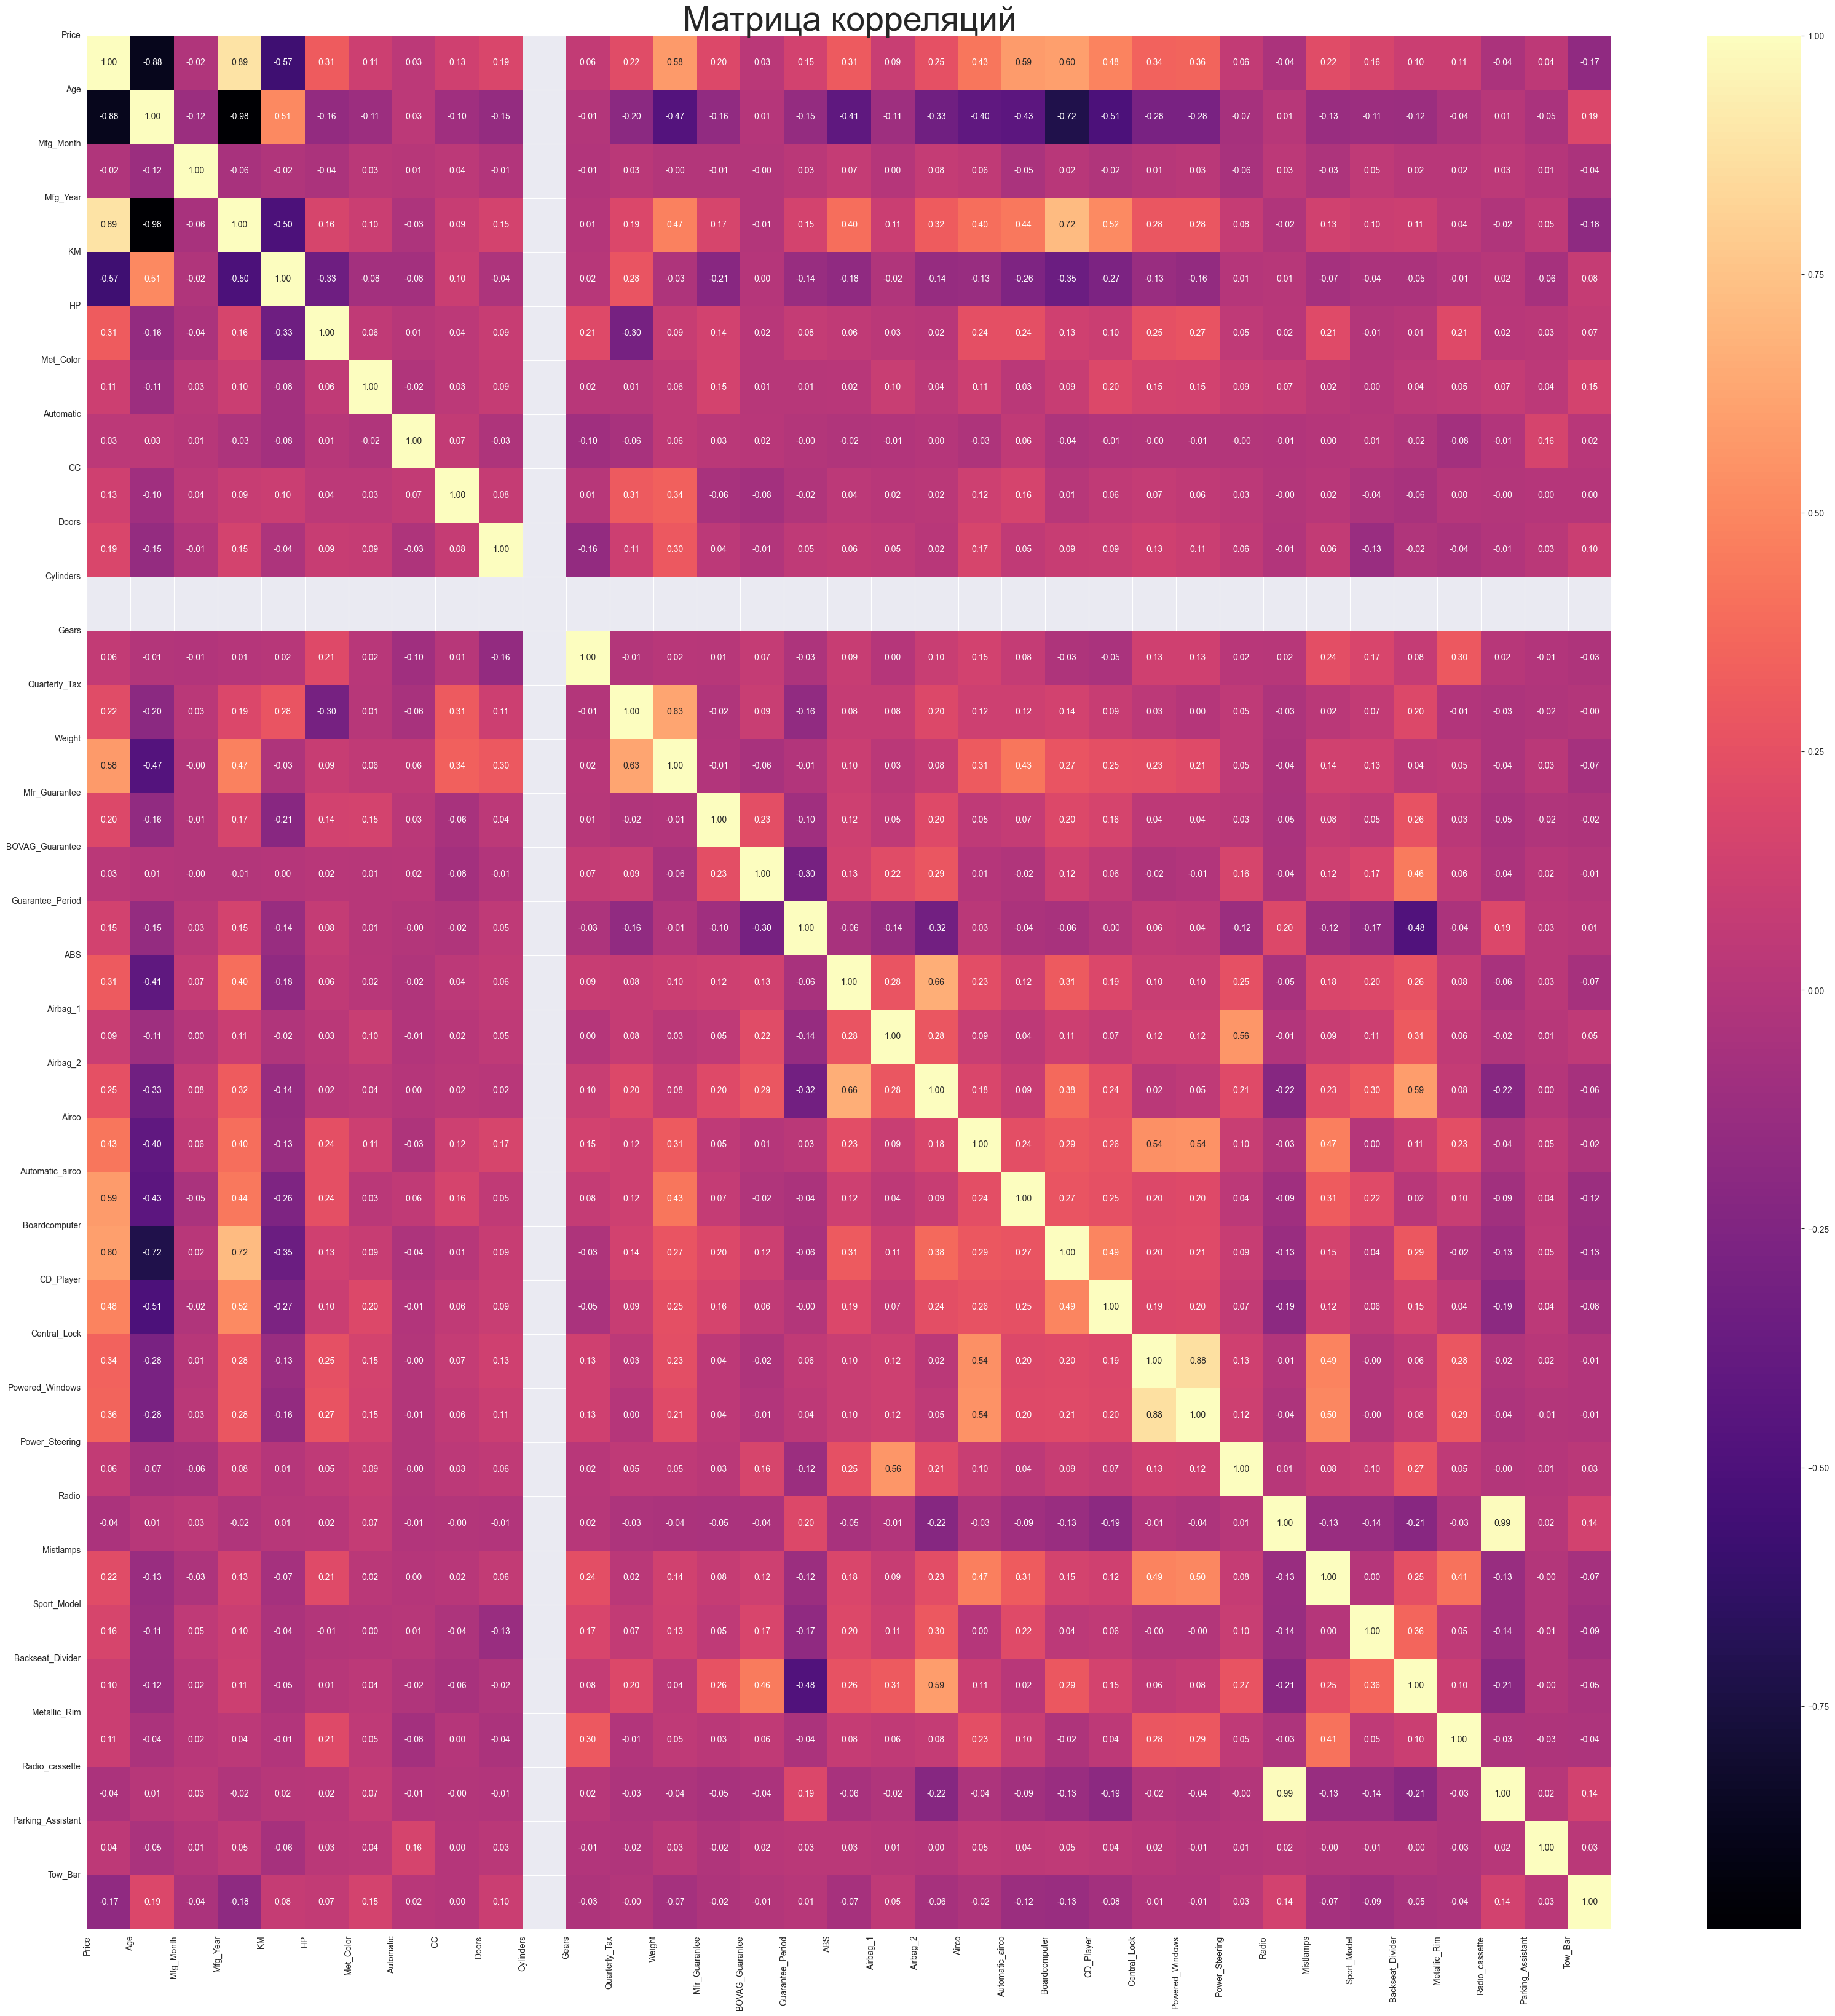

In [80]:
corr = dataset.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(40, 40))
sns.heatmap(corr, cmap='magma', annot=True, fmt=".2f")
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Матрица корреляций", fontsize=40)
plt.show()


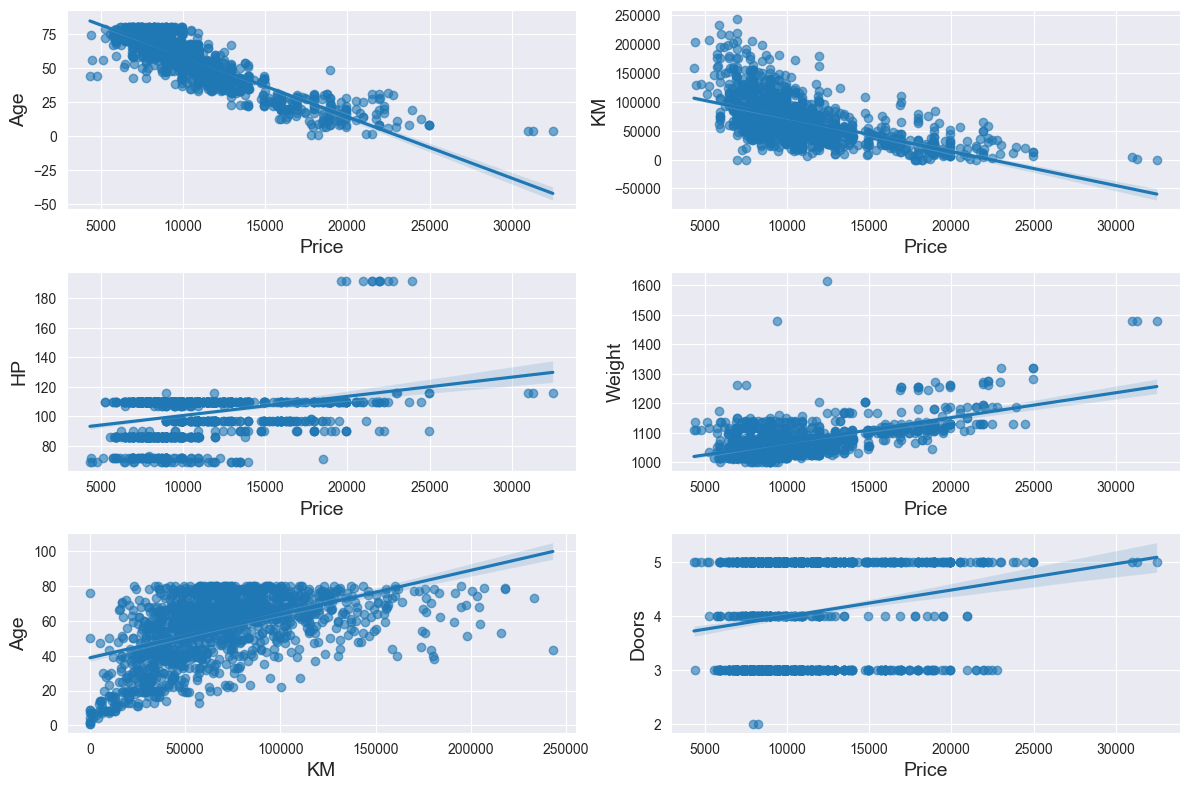

In [81]:
f, axes = plt.subplots(3, 2, figsize=(12,8))

sns.regplot(x='Price', y='Age', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[0,0])
axes[0,0].set_xlabel('Price', fontsize=14)
axes[0,0].set_ylabel('Age', fontsize=14)

sns.regplot(x='Price', y='KM', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[0,1])
axes[0,1].set_xlabel('Price', fontsize=14)
axes[0,1].set_ylabel('KM', fontsize=14)

sns.regplot(x='Price', y='HP', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[1,0])
axes[1,0].set_xlabel('Price', fontsize=14)
axes[1,0].set_ylabel('HP', fontsize=14)

sns.regplot(x='Price', y='Weight', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[1,1])
axes[1,1].set_xlabel('Price', fontsize=14)
axes[1,1].set_ylabel('Weight', fontsize=14)

sns.regplot(x='KM', y='Age', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[2,0])
axes[2,0].set_xlabel('KM', fontsize=14)
axes[2,0].set_ylabel('Age', fontsize=14)

sns.regplot(x='Price', y='Doors', data=dataset, scatter_kws={'alpha':0.6}, ax=axes[2,1])
axes[2,1].set_xlabel('Price', fontsize=14)
axes[2,1].set_ylabel('Doors', fontsize=14)

plt.tight_layout()
plt.show()

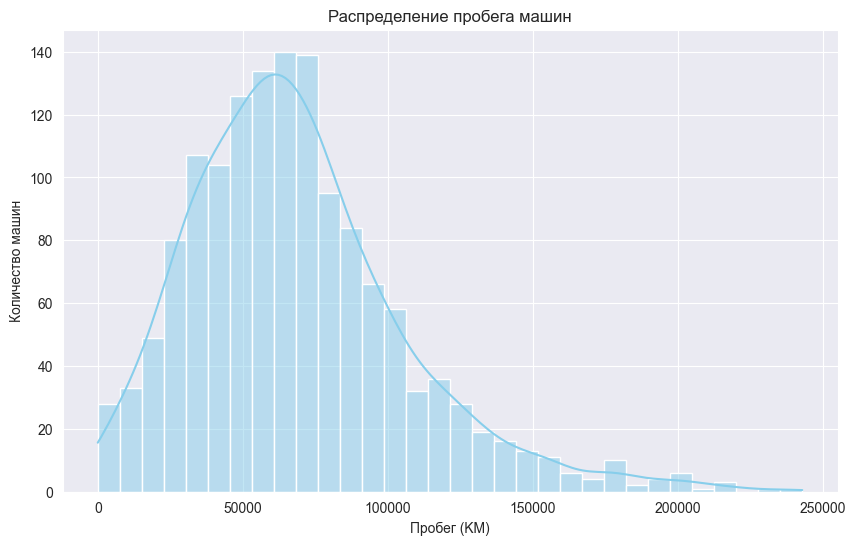

In [82]:
plt.figure(figsize=(10,6))

sns.histplot(x='KM', data=dataset, kde=True, color='skyblue')

plt.title('Распределение пробега машин')
plt.xlabel('Пробег (KM)')
plt.ylabel('Количество машин')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

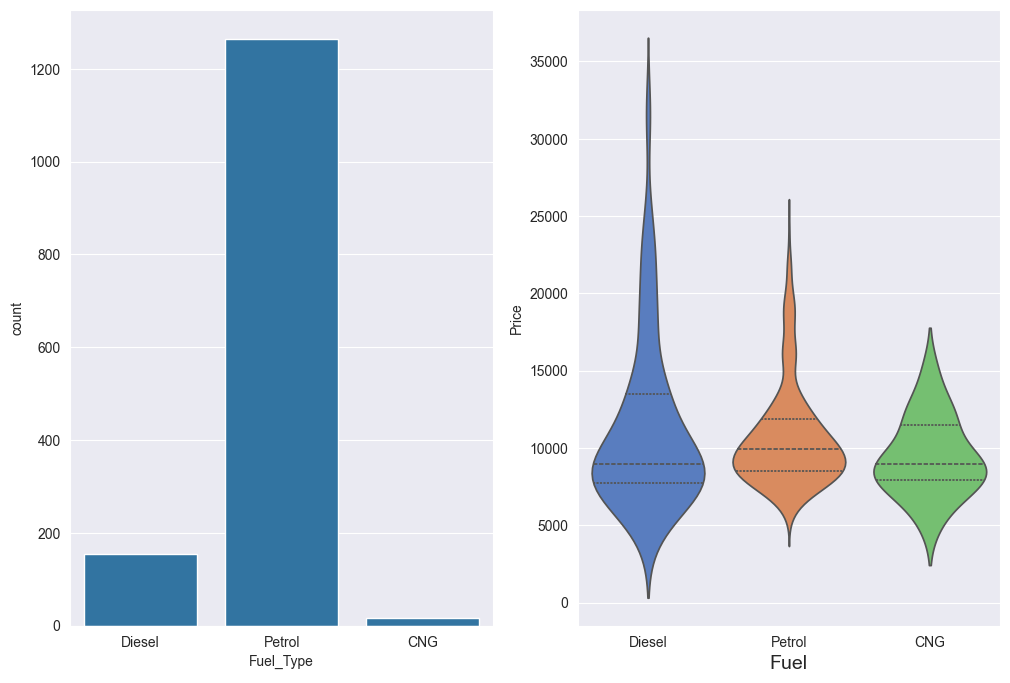

In [83]:

f, axes = plt.subplots(1, 2, figsize=(12,8))

sns.countplot(x='Fuel_Type', data=dataset, ax=axes[0])
axes[1].set_xlabel('Fuel', fontsize=14)

sns.violinplot(x='Fuel_Type', y='Price', data=dataset, palette='muted', inner='quartile', ax=axes[1])
axes[1].set_xlabel('Fuel', fontsize=14)

plt.show


3 Feature engineering

Можно убрать 'Model', 'Mfg_Month', 'Mfg_Year', 'Color'

In [84]:
dataset.drop(['Model', 'Mfg_Month', 'Mfg_Year', 'Color'], 
              axis=1, inplace=True)
dataset = pd.get_dummies(dataset, drop_first=True)
dataset.head(3)

,Price,Age,KM,HP,Met_Color,Automatic,CC,Doors,Cylinders,Gears,...,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,1,0,2000,3,4,5,...,0,0,0,1,0,0,0,0,True,False
1,13750,23,72937,90,1,0,2000,3,4,5,...,0,0,0,1,0,0,0,0,True,False
2,13950,24,41711,90,1,0,2000,3,4,5,...,0,0,0,1,0,0,0,0,True,False


4. Разделение выборки

In [85]:
X = dataset.drop('Price', axis=1).values
y = dataset['Price'].values.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Размер X_train: ", X_train.shape)
print("Размер X_test: ", X_test.shape)

Размер X_train:  (1148, 34)
Размер X_test:  (288, 34)


5 Обучение леса

In [90]:
rf_model = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_split=5, random_state=42)

cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_percentage_error')
print("CV MAPE:", -cv_scores.mean())
rf_model.fit(X_train, y_train)

y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

print("Метрики на обучающей выборке:")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("R2:", r2_score(y_train, y_train_pred))
print("MAPE:", mean_absolute_percentage_error(y_train, y_train_pred))

print("Метрики на тестовой выборке:")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))
print("MAPE:", mean_absolute_percentage_error(y_test, y_test_pred))

CV MAPE: 0.08041824696497565
Метрики на обучающей выборке:
MAE: 555.2523200179011
R2: 0.9603575154521676
MAPE: 0.05695187420912003
Метрики на тестовой выборке:
MAE: 744.142639699775
R2: 0.9280025529270071
MAPE: 0.07773905274946408


6 Обучение одного дерева

In [91]:
tree_model = DecisionTreeRegressor(max_depth=8, random_state=42)
tree_model.fit(X_train, y_train)
y_train_pred_tree = tree_model.predict(X_train)
y_test_pred_tree = tree_model.predict(X_test)

print("Метрики на обучающей выборке для дерева:")
print("MAE:", mean_absolute_error(y_train, y_train_pred_tree))
print("R2:", r2_score(y_train, y_train_pred_tree))
print("MAPE:", mean_absolute_percentage_error(y_train, y_train_pred_tree))

print("Метрики на тестовой выборке для дерева:")
print("MAE:", mean_absolute_error(y_test, y_test_pred_tree))
print("R2:", r2_score(y_test, y_test_pred_tree))
print("MAPE:", mean_absolute_percentage_error(y_test, y_test_pred_tree))

Метрики на обучающей выборке для дерева:
MAE: 541.2411086019698
R2: 0.9591566410355103
MAPE: 0.05656810515808108
Метрики на тестовой выборке для дерева:
MAE: 892.7970468838397
R2: 0.8909391245271406
MAPE: 0.09294518601946586


## 1. Разделение выборки

Подготовьте данные для обучения модели. 

**Обязательно объясните текстом:**
* **Сделали ли вы предобработку данных для случайного леса? Отличалась ли она от предобработки данных для линейной модели? Если до, то почему?** Для случайного леса надо убрать пропуски в данных; убрать фитчи, которые не несут смысла для прогноза; кодировать категориальные признаки; можно оставить коррелирующие признаки. Я убрал id, model (слишком сложно кодировать), mfg_month/year (тк это по факту age), color. Предобработка отличается, я не убирал фитчи, которые не сильно влияют на цену.
* **Как именно вы разделили выборку?** train - 80, test - 20
* **На сколько частей нужно делить выборку при использовании кросс-валидации?** 5 или 10
* **Можно ли не использовать кросс-валидацию? Если да, то как делить выборку в таком случае?** Да, можно. Если очень много данных или ограничены ресурсы. Тогда выборка делится на три части: train - 60-70%, validation (подбор гиперпараметров, например max_depth) - 15-20%, test 15-20%.


## 2. Обучение моделей

Обучите случайный лес. Обучите одно дерево той же глубины, какую вы укажете в случайном лесе. Сравните результаты.

**Вопросы для анализа:**
* **Сравнение скорости:** сравните, какая модель обучалась быстрее. Дерево обучилось быстрее.
* **Можно ли добиться одинаковой или близкой к одинаковой скорости?** Можно если использовать параллельные вычисления, сильно ограничить глубину леса, использовать разные подмножества признаков.
* **Сравнение качества:** сравните результаты одного дерева и случайного леса. Оба алгоритма переобучились, однако лес показал себя лучше на тесте.

## 3. Оценка качества и сравнение моделей

Сравните свои результаты с теми, которые вы получили от линейной регрессии.

**Ответьте на следующие вопросы: (если еще не отвечали в части про лин. рег)**
1. **Какие метрики вы использовали для сравнения моделей?** (Обоснуйте выбор: например, почему RMSE, а не MAE, или наоборот. Зачем нужен $R^2$?). MAPE тк анализируем рынок вторичных авто, где цена зависит от продавца. R^2 указывает, какую долю дисперсии целевой переменной объясняет модель
2. **На какой части выборки вы считали метрики?** На тестовой и обучающей
3. **Какая модель по итогу справилась лучше?** Если сравнивать лин рег и лес на тестовой выборке , то лес показал себя чуть лучше
4. **Насколько хорошие получились результаты?** Результаты хорошие, MAPE = 7.8% хороший результат для анализа вторичного рынка